# KNN을 이용해 설비용량 생성

## 데이터가 없는 지역에 대한 라벨링

- `최종2_지역코드_set.csv`를 이용해서 패널 데이터가 존재하는 지역별 df를 가져옴
- Clustering을 수행함.
- `최종_기반_기초자치단체~.csv`를 이용해서 KNN을 수행함.
- 시각화

결과 저장: /Users/mousebook/Documents/university/연구실/solar/generator/v2/source/클러스터_KDE_KNN_결과.csv


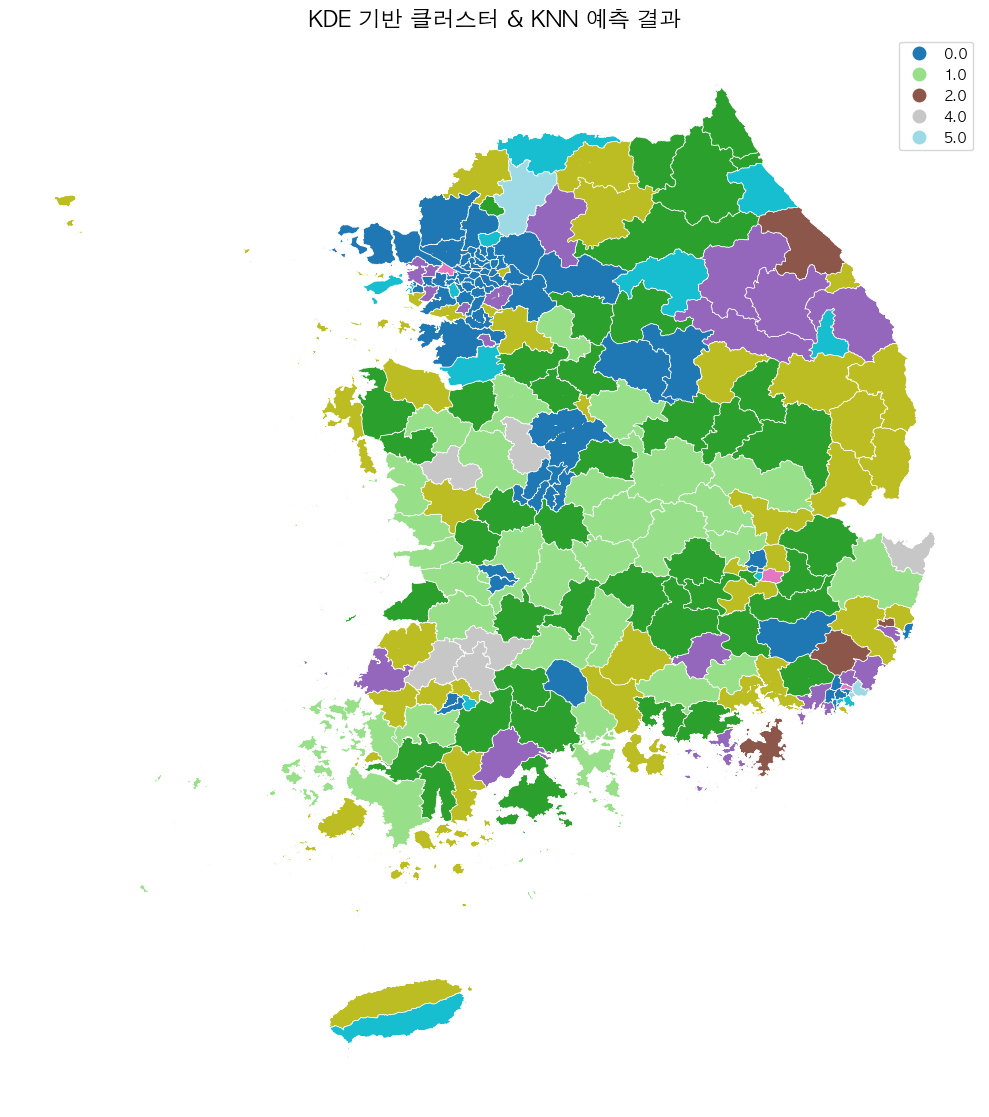

In [6]:
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# ─── 1. 경로 설정 ────────────────────────────────────────────
base_dir       = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
csv_panel_path = base_dir / "최종3.csv"
csv_region_sum = base_dir / "최종_기반_기초자치단체별_데이터2.csv"
csv_region_set = base_dir / "최종2_지역코드_set.csv"
gdf_pkl_path   = base_dir / "gdf_dict_v2.pkl"
codes_csv      = base_dir / "지역코드.csv"

# ─── 2. 패널 데이터 로드 및 KDE 계산 ───────────────────────────
df_panel = pd.read_csv(csv_panel_path, encoding="utf-8-sig")
df_panel["설비용량"] = pd.to_numeric(df_panel["설비용량"], errors="coerce")
df_panel["region"] = df_panel["region_1depth_name"] + " " + df_panel["region_2depth_name"]

# 그룹별 용량 배열
grouped = df_panel.groupby("region")["설비용량"].apply(lambda x: x.dropna().values)

# KDE 그리드
all_vals = df_panel["설비용량"].dropna().values
grid = np.linspace(all_vals.min(), all_vals.max(), 100)

# KDE 매트릭스 & 레이블 (패널 수가 5개 이상인 지역만)
kde_list, kde_regions = [], []
for region, vals in grouped.items():
    if len(vals) < 5:
        continue
    kde_list.append(gaussian_kde(vals)(grid))
    kde_regions.append(region)
kde_matrix = np.vstack(kde_list)

# ─── 3. 계층적 군집화 수행 ─────────────────────────────────────
n_clusters = 6
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
region_clusters = agg.fit_predict(kde_matrix)

df_cluster = pd.DataFrame({
    "region": kde_regions,
    "region_cluster": region_clusters
})

# ─── 4. 지역 요약 데이터 로드 및 병합 ─────────────────────────
df_region = pd.read_csv(csv_region_sum, encoding="utf-8-sig")
df_region = df_region.merge(df_cluster, on="region", how="left")

# ─── 5. KNN 학습 및 예측 ─────────────────────────────────────
features = ["centroid_lon", "centroid_lat", "b_count", "b_capacity_MW", "전년도발전용량"]
train_df = df_region[df_region["region_cluster"].notna()].copy()
test_df  = df_region[df_region["region_cluster"].isna()].copy()

X_train = train_df[features]
y_train = train_df["region_cluster"].astype(int)
X_test  = test_df[features]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
test_df["predicted_cluster"] = knn.predict(X_test_s).astype(int)

# 모든 결과 합치기
df_result = pd.concat([train_df, test_df], ignore_index=True)

# ─── 6. 결과 저장 ─────────────────────────────────────────────
output_csv = base_dir / "클러스터_KDE_KNN_결과.csv"
df_result.to_csv(output_csv, index=False, encoding="utf-8-sig")
print(f"결과 저장: {output_csv}")

# ─── 7. 지도 시각화 ──────────────────────────────────────────
with open(gdf_pkl_path, "rb") as f:
    gdf_dict = pickle.load(f)
gdf_all = gpd.GeoDataFrame(pd.concat(gdf_dict.values(), ignore_index=True),
                           crs=list(gdf_dict.values())[0].crs)

# 지역명 매핑
mapping = pd.read_csv(codes_csv, encoding="utf-8-sig", header=0, names=["region", "region_code"])
mapping["region_code"] = mapping["region_code"].astype(int)

# split을 키워드 인자로 지정
parts = mapping["region"].str.split(pat=" ", n=1, expand=True)
mapping["region_1depth_name"] = parts[0]
mapping["region_2depth_name"] = parts[1]
mapping["region"] = parts[0] + " " + parts[1]

# SIG_CD 타입 맞추기
gdf_all["SIG_CD"] = gdf_all["SIG_CD"].astype(int)

# GeoDataFrame에 병합
gdf_all = gdf_all.merge(
    mapping[["region_code", "region"]],
    left_on="SIG_CD", right_on="region_code", how="left"
)
gdf_all = gdf_all.merge(
    df_result[["region", "region_cluster", "predicted_cluster"]],
    on="region", how="left"
)

# 플롯 설정
plt.rc("font", family="AppleGothic")
plt.rc("axes", unicode_minus=False)

fig, ax = plt.subplots(figsize=(10, 12))
# 관측된 클러스터
gdf_all.dropna(subset=["region_cluster"]).plot(
    column="region_cluster",
    categorical=True,
    cmap="tab10",
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.5
)
# 예측된 클러스터
gdf_all[gdf_all["region_cluster"].isna()].plot(
    column="predicted_cluster",
    categorical=True,
    cmap="tab20",
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.5
)
ax.set_title("KDE 기반 클러스터 & KNN 예측 결과", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


클러스터링 수행 이후 데이터가 없는 지역의 `설비용량` 을 생성
생성 시에는 해당 지역의 `클러스터별 평균 밀도 함수`를 이용해서 생성한다.

In [7]:
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# ─── 1. 경로 설정 ────────────────────────────────────────────
base_dir       = Path("/Users/mousebook/Documents/university/연구실/solar/generator/v2/source")
csv_panel_path = base_dir / "최종3.csv"
csv_region_sum = base_dir / "최종_기반_기초자치단체별_데이터2.csv"
csv_region_set = base_dir / "최종2_지역코드_set.csv"
gdf_pkl_path   = base_dir / "gdf_dict_v2.pkl"
codes_csv      = base_dir / "지역코드.csv"

# ─── 2. 패널 데이터 로드 및 KDE 계산 ───────────────────────────
df_panel = pd.read_csv(csv_panel_path, encoding="utf-8-sig")
df_panel["설비용량"] = pd.to_numeric(df_panel["설비용량"], errors="coerce")
df_panel["region"] = df_panel["region_1depth_name"] + " " + df_panel["region_2depth_name"]

# 그룹별 용량 배열
grouped = df_panel.groupby("region")["설비용량"].apply(lambda x: x.dropna().values)

# KDE 그리드
all_vals = df_panel["설비용량"].dropna().values
grid = np.linspace(all_vals.min(), all_vals.max(), 100)

# KDE 매트릭스 & 레이블 (패널 수가 5개 이상인 지역만)
kde_list, kde_regions = [], []
for region, vals in grouped.items():
    if len(vals) < 5:
        continue
    kde_list.append(gaussian_kde(vals)(grid))
    kde_regions.append(region)
kde_matrix = np.vstack(kde_list)

# ─── 3. 계층적 군집화 수행 ─────────────────────────────────────
n_clusters = 6
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
region_clusters = agg.fit_predict(kde_matrix)

df_cluster = pd.DataFrame({
    "region": kde_regions,
    "region_cluster": region_clusters
})

# ─── 4. 지역 요약 데이터 로드 및 병합 ─────────────────────────
df_region = pd.read_csv(csv_region_sum, encoding="utf-8-sig")
df_region = df_region.merge(df_cluster, on="region", how="left")

# ─── 5. 클러스터별 평균 KDE 계산 ───────────────────────────────
cluster_mean_kde = {}
for c in range(n_clusters):
    idx = np.where(region_clusters == c)[0]
    cluster_mean_kde[c] = kde_matrix[idx].mean(axis=0)

# ─── 6. KNN 학습 및 예측 ─────────────────────────────────────
features = ["centroid_lon", "centroid_lat", "b_count", "b_capacity_MW", "전년도발전용량"]
train_df = df_region[df_region["region_cluster"].notna()].copy()
test_df  = df_region[df_region["region_cluster"].isna()].copy()

X_train = train_df[features]
y_train = train_df["region_cluster"].astype(int)
X_test  = test_df[features]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
test_df["predicted_cluster"] = knn.predict(X_test_s).astype(int)

# ─── 7. 결측 지역별 샘플링 및 스케일링 ─────────────────────────
def sample_and_scale(kde_vals, grid, count, total_capacity):
    # 확률 밀도 → 확률 분포
    probs = kde_vals / kde_vals.sum()
    # grid에서 count개 샘플
    samples = np.random.choice(grid, size=count, p=probs)
    current_sum = samples.sum()
    if current_sum > 0:
        samples *= (total_capacity / current_sum)
    return samples

# 각 예측 지역에 대해
synthetic = {}
for _, row in test_df.iterrows():
    c = row["predicted_cluster"]
    kde_vals = cluster_mean_kde[c]
    cnt = int(row["b_count"])
    tot = float(row["b_capacity_MW"])
    samples = sample_and_scale(kde_vals, grid, cnt, tot)
    synthetic[row["region"]] = samples

# synthetic 에는 'region': array([...]) 형태로 저장됨

# ─── 8. 결과 저장 ─────────────────────────────────────────────
# 예: 전체 synthetic 값을 별도 pickle 로 저장
import pickle
with open(base_dir / "synthetic_panels.pkl", "wb") as f:
    pickle.dump(synthetic, f)

# test_df 는 predicted_cluster 포함
output_csv = base_dir / "클러스터_KDE_KNN_결과.csv"
test_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
print(f"결과 저장: {output_csv}, synthetic panels pickled.")


결과 저장: /Users/mousebook/Documents/university/연구실/solar/generator/v2/source/클러스터_KDE_KNN_결과.csv, synthetic panels pickled.


1. 위치
- 공공시설 근처에 패널이 섪치될 수 있다.
- 지역별 위치를 clustering을 하면은 각 cluster가 conidition이 될 수 있음.

2. 위치 - rate
- random missing -> 수학적 모델링으로 location을 생성하면 되지 않을지
- missing rate가 높으면, KDE + radom 을 mixin
- 그러기 위해서 missing rate를 계층화
- 학교와 태양광 패널의 유사성 확인해보기 (ex. 제주시) -> 학교에 태양광 패널이 있을 가능성 높음.



# 지역별 산지, 비산지 분포와 패널의 분포가 상관관계를 가질지

In [ ]:
import numpy as np
import pandas as pd
from shapely.geometry import Point
from shapely.affinity import translate, scale
from skimage.metrics import structural_similarity as ssim
import utils
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import geopandas as gpd

# 1. 설정
RASTER_SIZE = 100      # 래스터 해상도
SSIM_WIN = 11          # SSIM 윈도우 크기
N_CLUSTERS = 5         # 찾을 클러스터 수
PLOT_PER_CLUSTER = 3   # 각 클러스터에서 랜덤 샘플 개수

# 2. 폴리곤을 [0,1]^2로 정규화 후 바이너리 마스크 생성
def rasterize_mask(poly, size=RASTER_SIZE):
    xs = np.linspace(0, 1, size)
    ys = np.linspace(0, 1, size)
    mask = np.zeros((size, size), dtype=np.uint8)
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            if poly.contains(Point(x, y)):
                mask[i, j] = 1
    return mask

# 3. 각 지역의 산지 마스크 계산
pairs = utils.load_region_pairs()  # [(depth1, depth2), ...]
region_keys = []
masks = []
gdfs = []  # 원본 지오데이터프레임 저장
for depth1, depth2 in pairs:
    _, code, gdf_region = utils.filter_region_and_get_code_and_geom(depth1, depth2)
    poly = gdf_region['Mountain Area'].iloc[0]
    minx, miny, maxx, maxy = poly.bounds
    poly_t = translate(poly, xoff=-minx, yoff=-miny)
    poly_norm = scale(poly_t,
                      xfact=1/(maxx-minx),
                      yfact=1/(maxy-miny),
                      origin=(0, 0))
    mask = rasterize_mask(poly_norm)
    region_keys.append(f"{depth1}_{depth2}")
    masks.append(mask)
    gdfs.append(gdf_region)

# 4. SSIM 유사도 행렬 계산
n = len(masks)
ssim_matrix = np.zeros((n, n), dtype=float)
for i in range(n):
    for j in range(i, n):
        score = ssim(
            masks[i], masks[j],
            win_size=SSIM_WIN,
            data_range=1.0,
            K1=0.01,
            K2=0.03,
            gaussian_weights=True
        )
        ssim_matrix[i, j] = score
        ssim_matrix[j, i] = score

# 5. 클러스터링
clustering = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    affinity='precomputed',
    linkage='average'
)
# 거리는 1-유사도로 변환
dist_matrix = 1 - ssim_matrix
labels = clustering.fit_predict(dist_matrix)

# 6. 각 클러스터별 일부 지역 시각화
for cluster_id in range(N_CLUSTERS):
    idxs = np.where(labels == cluster_id)[0]
    sample_idxs = np.random.choice(idxs, min(PLOT_PER_CLUSTER, len(idxs)), replace=False)
    fig, axes = plt.subplots(1, len(sample_idxs), figsize=(4*len(sample_idxs), 4))
    for ax, idx in zip(np.atleast_1d(axes), sample_idxs):
        key = region_keys[idx]
        gdf_region = gdfs[idx]
        # 원래 좌표로 플롯
        gdf_region.boundary.plot(ax=ax, color='black', linewidth=1)
        gpd.GeoSeries(gdf_region['Mountain Area'], crs=gdf_region.crs).plot(
            ax=ax, color='green', alpha=0.6
        )
        ax.set_title(f"{key}\nCluster {cluster_id}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()


KeyboardInterrupt: 